# Import Libraries

In [40]:
import pandas as pd
import numpy as np
import seaborn as  sns
import matplotlib.pyplot as plt


from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error


# Import Data

In [41]:
df_prices=pd.read_csv('data/prices.csv',sep=';')
df_prices["Date"] = pd.to_datetime(df_prices["Date"], format="%m/%d/%Y")
df_prices["Value"] = (
    df_prices["Value"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)
df_prices.head()

,Date,Value
0,1969-06-02,0.3725
1,1969-06-03,0.3725
2,1969-06-04,0.3725
3,1969-06-05,0.3725
4,1969-06-06,0.3725


In [42]:

df_monthly = (
    df_prices
    .set_index("Date")
    .resample("M")
    .median()
)


C:\Users\ferna\AppData\Local\Temp\ipykernel_3368\208174075.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


# Data Cleaning and Understanding

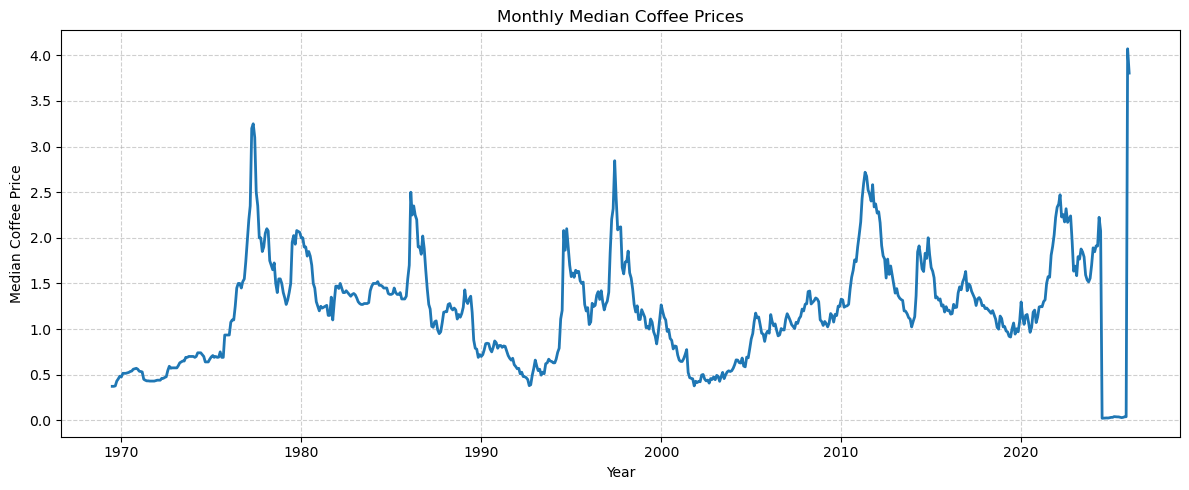

In [43]:
plt.figure(figsize=(12, 5))
plt.plot(df_monthly.index, df_monthly["Value"], linewidth=2)

plt.xlabel("Year")
plt.ylabel("Median Coffee Price")
plt.title("Monthly Median Coffee Prices")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


The original dataset contains daily coffee price observations up to December 2025. However, from 2024 onward, the data presents incomplete temporal coverage, with several months containing missing or insufficient observations. To avoid distortions in aggregation, visualization, and time series modeling, the dataset was truncated at December 2023, retaining only periods with reliable and consistent data.


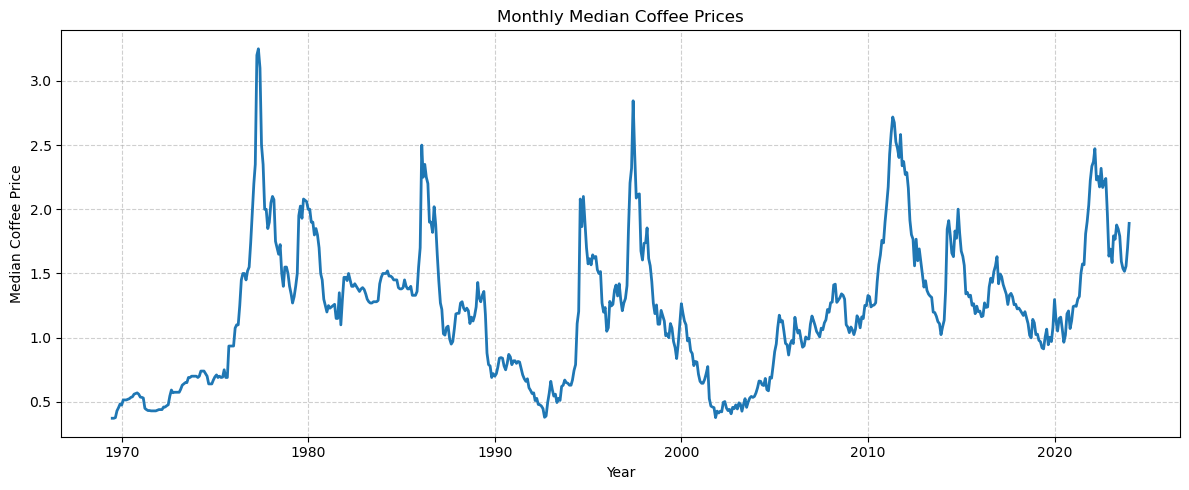

In [44]:
df_monthly = df_monthly.loc[: "2023-12-31"]
plt.figure(figsize=(12, 5))
plt.plot(df_monthly.index, df_monthly["Value"], linewidth=2)

plt.xlabel("Year")
plt.ylabel("Median Coffee Price")
plt.title("Monthly Median Coffee Prices")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Seasonal Decomposition

To better understand the underlying structure of the monthly coffee price series, a seasonal decomposition was applied.  
This technique separates the original time series into four components:

$$
\text{Value} = \text{Trend} + \text{Seasonal} + \text{Residual}
$$
An **additive decomposition** was used, as the magnitude of seasonal fluctuations remains approximately constant over time.

---

### Value (Observed)

The *Value* component represents the original monthly median coffee price series.  
It reflects the combined effects of long-term trends, recurring seasonal patterns, and irregular fluctuations.

This series exhibits pronounced multi-year cycles and varying volatility, indicating that the data is not purely random.

---

### Trend

The *Trend* component captures the long-term movement of coffee prices by smoothing out short-term fluctuations and seasonal effects.

It highlights extended periods of price increase and decrease, revealing cyclical behavior typical of agricultural commodity markets.

---

### Seasonal

The *Seasonal* component represents the recurring annual pattern observed in the data.  
It captures systematic month-to-month variations that repeat consistently each year.

The presence of a stable seasonal pattern supports the use of seasonal time series models such as **SARIMA**.

---

### Residual

The *Residual* component contains the remaining variation after removing both trend and seasonal effects.

Ideally, residuals should resemble random noise with no clear structure.  
The absence of strong patterns in this component indicates that the main temporal dynamics are well explained by the trend and seasonal components.

---

### Interpretation

The decomposition reveals that monthly coffee prices are driven by a combination of long-term cycles and recurring seasonal effects, with residual fluctuations largely unstructured.  
This diagnostic step provides essential guidance for subsequent stationarity testing and model selection.


C:\Users\ferna\AppData\Local\Temp\ipykernel_3368\387938563.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = ts.asfreq("M")


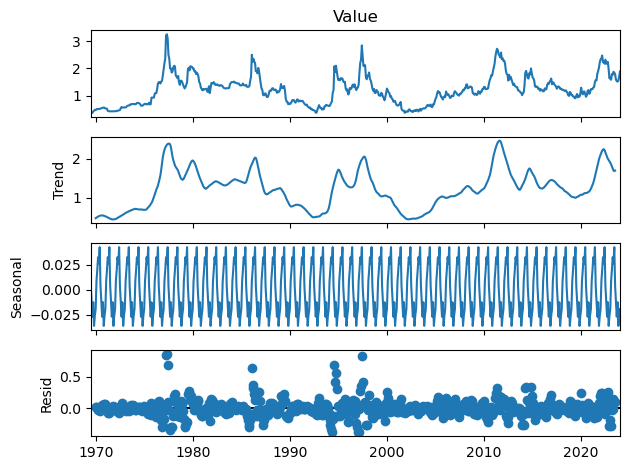

In [45]:
ts = df_monthly["Value"]
ts = ts.asfreq("M")

decomp = seasonal_decompose(
    ts,
    model="additive",
    period=12
)

decomp.plot()
plt.tight_layout()
plt.show()


## Stationarity Test (ADF)

To assess whether the time series is stationary, the **Augmented Dickey-Fuller (ADF)** test was applied to the monthly price series.

### Hypotheses

- **Null hypothesis (H₀)**: the time series contains a **unit root**, meaning it is **non-stationary**.
- **Alternative hypothesis (H₁)**: the time series does **not** contain a unit root and is therefore **stationary**.

The ADF test evaluates the null hypothesis that the series contains a unit root, which implies non-stationarity.  
In contrast, the alternative hypothesis assumes that the series is stationary.

The test outputs two key values:

- **ADF Statistic**: a test statistic used to evaluate the presence of a unit root.
- **p-value**: the probability of observing the test statistic under the null hypothesis.

### Interpretation

- If **p-value ≤ 0.05**, the null hypothesis is rejected, indicating that the series is stationary.
- If **p-value > 0.05**, the null hypothesis cannot be rejected, suggesting that the series is non-stationary.

This test provides statistical guidance for deciding whether differencing is required before fitting ARIMA or SARIMA models.

In [46]:

result = adfuller(ts)

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")


ADF Statistic: -4.0478
p-value: 0.0012


Although the ADF test rejects the null hypothesis of a unit root, the original series exhibits long-term trends and cyclical behavior. Therefore, the series is not strictly stationary in a practical sense, motivating the evaluation of both differenced and non-differenced models.



<Figure size 1200x400 with 0 Axes>

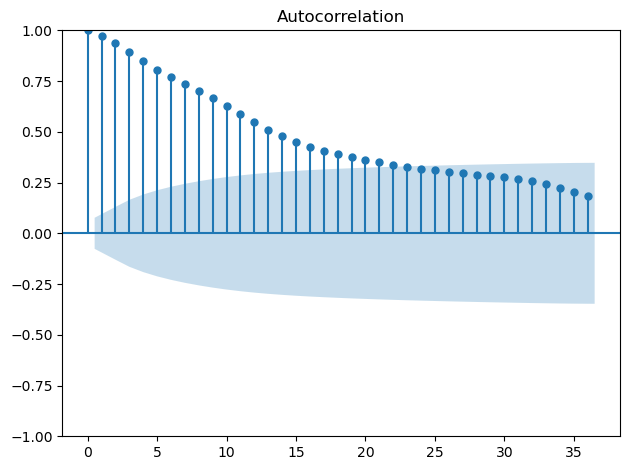

<Figure size 1200x400 with 0 Axes>

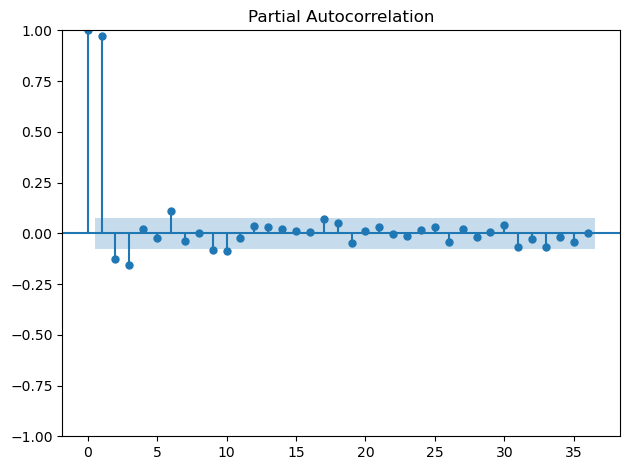

In [47]:
ts_used = ts  # ou ts.diff().dropna()

plt.figure(figsize=(12, 4))
plot_acf(ts_used, lags=36)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plot_pacf(ts_used, lags=36)
plt.tight_layout()
plt.show()

## Autocorrelation Analysis (ACF and PACF)

To further investigate the temporal dependence structure of the monthly coffee price series, the **Autocorrelation Function (ACF)** and **Partial Autocorrelation Function (PACF)** were analyzed. These diagnostics help identify the presence of long-term memory and guide the selection of ARIMA/SARIMA model orders.

---

### Autocorrelation Function (ACF)

The ACF plot shows **very high autocorrelation at low lags**, followed by a **slow and gradual decay** across many subsequent lags. A large number of autocorrelations remain statistically significant, extending well beyond short-term horizons.

This pattern indicates **strong temporal dependence and long-term memory**, which is characteristic of series exhibiting trends or multi-year cycles rather than purely random fluctuations. The absence of a sharp cutoff suggests that the series is not dominated by a simple moving average process.

Overall, the ACF provides evidence that the original series is **not stationary in a practical sense**, as past values continue to influence the present over extended periods.

---

### Partial Autocorrelation Function (PACF)

The PACF plot reveals **strong and statistically significant spikes at lags 1 and 2**, followed by a clear drop, with subsequent lags largely falling within the confidence bounds.

This behavior indicates that the current value of the series is **directly influenced by the two most recent observations**, while higher-order dependencies are largely indirect. Such a sharp cutoff in the PACF is a classical signature of an **autoregressive process of order 2 (AR(2))**.

---

### Joint Interpretation

Taken together, the ACF and PACF plots suggest that:

- The series exhibits **long-term dependence and memory**, consistent with the presence of trends or cycles.
- Short-term dynamics are primarily governed by an **autoregressive structure**, with direct dependence up to lag 2.
- The moving average component is likely limited, as no clear cutoff is observed in the ACF.

These diagnostics motivate the use of models with:
- An autoregressive order of **p = 2**
- Consideration of differencing (**d = 0 or d = 1**) due to long-term dependence
- Optional seasonal components, as identified in the seasonal decomposition

This analysis provides a principled foundation for the subsequent specification and comparison of ARIMA and SARIMA models.



# Arima

The **ARIMA (AutoRegressive Integrated Moving Average)** model is a classical statistical approach for modeling and forecasting univariate time series.  
It assumes that future values of a series can be explained as a linear combination of past observations and past forecast errors, after appropriate transformations to ensure stationarity.

ARIMA models are particularly suitable for time series that exhibit temporal dependence but do not require external explanatory variables.

---

### Model Structure: ARIMA(p, d, q)

An ARIMA model is fully defined by three parameters:

- **p**: order of the autoregressive (AR) component  
- **d**: order of differencing required to achieve stationarity  
- **q**: order of the moving average (MA) component  

Each component captures a different aspect of the time series dynamics.

---

### Autoregressive Component (p)

The autoregressive part models the dependence between the current value and its previous values.

- A model with `p = 1` uses the immediately preceding observation.
- A model with `p = 2` uses the two most recent observations, and so on.

The value of `p` reflects how many past time steps have a **direct influence** on the current observation, as suggested by the PACF analysis.

---

### Integrated Component (d)

The integrated component represents the number of times the series is differenced to remove non-stationarity.

- `d = 0` indicates that the series is modeled in its original form.
- `d = 1` indicates that first-order differencing is applied.
- Higher values of `d` are rarely required in practice.

Differencing is used to stabilize the mean of the series and ensure that the statistical properties remain consistent over time.

---

### Moving Average Component (q)

The moving average part captures the dependence between the current value and past forecast errors.

- A model with `q = 1` incorporates the most recent prediction error.
- Larger values of `q` account for longer error memory.

The value of `q` is typically guided by the ACF analysis.

---

### Practical Considerations

ARIMA models rely on the assumption that the underlying data-generating process remains stable over time.  
As a result, they are effective for capturing short- to medium-term dynamics but may struggle with structural breaks or sudden regime changes.

For this reason, multiple ARIMA configurations are often evaluated and compared using out-of-sample performance metrics.


In [48]:
train = ts.loc[: "2015-12-31"]
test  = ts.loc["2016-01-31":]


In [49]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

In [50]:
def fit_arima(order, train, test):

    model = ARIMA(train, order=order)
    fit = model.fit()
    pred = fit.forecast(steps=len(test))
    pred.index = test.index

    mae, rmse = compute_metrics(test, pred)

    return {
        "p": order[0],
        "d": order[1],
        "q": order[2],
        "AIC": fit.aic,
        "MAE": mae,
        "RMSE": rmse
    }


In [51]:
results = []

for p in range(0, 4):
    for d in [0, 1]:
        for q in range(0, 3):

            res = fit_arima((p, d, q), train, test)
            if res is not None:
                results.append(res)

import pandas as pd
results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

c:\Users\ferna\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\ferna\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\ferna\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\ferna\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\ferna\anaconda3\Lib\site-packages\stat

,p,d,q,AIC,MAE,RMSE
23,3,1,2,-785.534804,0.312698,0.406523
4,0,1,1,-762.906052,0.324772,0.460850
9,1,1,0,-766.188252,0.324845,0.460968
3,0,1,0,-756.244963,0.325113,0.461393
10,1,1,1,-771.377095,0.325957,0.462725
11,1,1,2,-780.733357,0.327440,0.465040
5,0,1,2,-781.931610,0.327575,0.465269
15,2,1,0,-781.789251,0.327953,0.465818
21,3,1,0,-782.092843,0.328428,0.466571
22,3,1,1,-780.045606,0.328520,0.466710


A grid of ARIMA(p, d, q) models was evaluated using out-of-sample error metrics.  
While the configuration ARIMA(3,1,2) achieved the lowest RMSE, the performance gains relative to simpler models were marginal.

Across all well-performing models, differencing (d = 1) proved essential, indicating that removing long-term dependence is the dominant factor in improving forecasts. Variations in p and q yielded only minor refinements.

Given the small performance differences and the increased complexity of higher-order models, simpler specifications such as ARIMA(1,1,0) or ARIMA(0,1,1) are preferred for robustness and interpretability.

# SARIMA

The **SARIMA (Seasonal AutoRegressive Integrated Moving Average)** model extends ARIMA by explicitly incorporating seasonal patterns in the data.  
It is designed for time series where observations exhibit regular periodic behavior, such as monthly or quarterly seasonality.

SARIMA models are particularly useful when both short-term dynamics and recurring seasonal effects influence the series.

---

### Model Structure: SARIMA(p, d, q)(P, D, Q, s)

A SARIMA model is defined by two sets of parameters:

#### Non-seasonal parameters
- **p**: autoregressive order
- **d**: differencing order
- **q**: moving average order

#### Seasonal parameters
- **P**: seasonal autoregressive order
- **D**: seasonal differencing order
- **Q**: seasonal moving average order
- **s**: seasonal period (s = 12 for monthly data)

The non-seasonal parameters capture short-term dependencies, while the seasonal parameters model recurring patterns across fixed intervals.

---

### Practical Considerations

While SARIMA can capture seasonal structure, it remains a univariate linear model and assumes that historical seasonal patterns persist into the future.  
As a result, its performance may be limited in the presence of structural breaks or irregular shocks.

In [52]:
def fit_sarima(order, seasonal_order, train, test):
    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)

    pred = fit.forecast(steps=len(test))
    pred.index = test.index

    mae, rmse = compute_metrics(test, pred)

    return {
        "p": order[0],
        "d": order[1],
        "q": order[2],
        "P": seasonal_order[0],
        "D": seasonal_order[1],
        "Q": seasonal_order[2],
        "s": seasonal_order[3],
        "AIC": fit.aic,
        "MAE": mae,
        "RMSE": rmse
    }

In [53]:
results = []

for p in range(0, 3):
    for q in range(0, 3):
        for P in [0, 1]:
            for Q in [0, 1]:

                order = (p, 1, q)
                seasonal_order = (P, 0, Q, 12)

                res = fit_sarima(order, seasonal_order, train, test)
                if res is not None:
                    results.append(res)
sarima_results = pd.DataFrame(results).sort_values("RMSE")
sarima_results

c:\Users\ferna\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,p,d,q,P,D,Q,s,AIC,MAE,RMSE
1,0,1,0,0,0,1,12,-725.380583,0.319069,0.450878
3,0,1,0,1,0,1,12,-723.414718,0.319242,0.450942
2,0,1,0,1,0,0,12,-727.615150,0.319251,0.451433
5,0,1,1,0,0,1,12,-729.141660,0.319761,0.452167
7,0,1,1,1,0,1,12,-727.165603,0.319871,0.452185
6,0,1,1,1,0,0,12,-733.740051,0.319935,0.452648
15,1,1,0,1,0,1,12,-732.553479,0.320362,0.453144
13,1,1,0,0,0,1,12,-734.537759,0.320293,0.453152
14,1,1,0,1,0,0,12,-734.479095,0.320461,0.453562
19,1,1,1,1,0,1,12,-735.060854,0.322040,0.456035


A grid of SARIMA(p, d, q)(P, D, Q, 12) models was evaluated to assess the contribution of explicit seasonal components. Across all configurations, differencing (d = 1) remained essential, consistent with the ARIMA results.

Although some SARIMA specifications achieved lower AIC values, the out-of-sample error metrics (MAE and RMSE) showed only marginal variation and did not outperform the best ARIMA models.  
This indicates that, while seasonal patterns are present in the data, they do not play a dominant role in short- to medium-term forecasting performance.

Overall, the results suggest that increasing model complexity through seasonal components does not yield meaningful predictive gains, and simpler ARIMA specifications remain preferable for robustness and interpretability.

## Final Model Comparison: ARIMA vs SARIMA

Based on the hyperparameter evaluation, the best-performing configurations for each model class were selected according to out-of-sample error metrics.

| Model | Specification | MAE | RMSE |
|------|---------------|-----|------|
| ARIMA | ARIMA(3,1,2) | 0.3127 | 0.4065 |
| SARIMA | SARIMA(0,1,0)(0,0,1,12) | 0.3191 | 0.4509 |

### Interpretation

- The **ARIMA model achieves lower MAE and RMSE**, indicating superior predictive accuracy on the test set.
- Although SARIMA explicitly models seasonality, its forecasts do **not outperform ARIMA**, suggesting that seasonal effects are not the dominant driver of short- to medium-term price dynamics.
- The performance gap remains consistent across multiple configurations, reinforcing the robustness of this conclusion.

In [54]:
best_arima = results_df.iloc[0]

best_arima_order = (
    int(best_arima["p"]),
    int(best_arima["d"]),
    int(best_arima["q"])
)


arima_final = ARIMA(train, order=best_arima_order)
arima_final_fit = arima_final.fit()

arima_pred = arima_final_fit.forecast(steps=len(test))
arima_pred.index = test.index

c:\Users\ferna\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\ferna\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\ferna\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [55]:
best_sarima = sarima_results.iloc[0]

best_sarima_order = (
    int(best_sarima["p"]),
    int(best_sarima["d"]),
    int(best_sarima["q"])
)

best_sarima_seasonal = (
    int(best_sarima["P"]),
    int(best_sarima["D"]),
    int(best_sarima["Q"]),
    int(best_sarima["s"])
)

sarima_final = SARIMAX(
    train,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_final_fit = sarima_final.fit(disp=False)

sarima_pred = sarima_final_fit.forecast(steps=len(test))
sarima_pred.index = test.index

In [56]:
arima_mae, arima_rmse = compute_metrics(test, arima_pred)
sarima_mae, sarima_rmse = compute_metrics(test, sarima_pred)

arima_mae, arima_rmse, sarima_mae, sarima_rmse

(0.3126980642230074,
 np.float64(0.40652322775397043),
 0.3190688787119313,
 np.float64(0.45087787778837574))

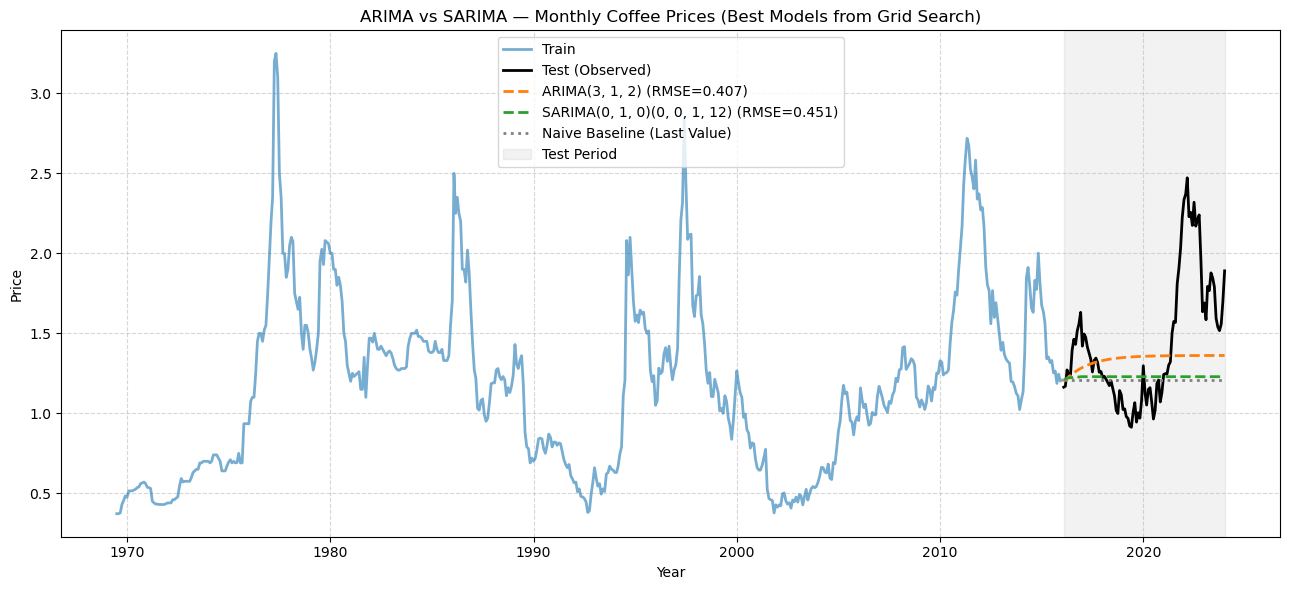

In [57]:
plt.figure(figsize=(13, 6))

# Train / Test
plt.plot(train.index, train, label="Train", alpha=0.6, linewidth=2)
plt.plot(test.index, test, label="Test (Observed)", color="black", linewidth=2)

# Forecasts
plt.plot(
    arima_pred.index,
    arima_pred,
    "--",
    linewidth=2,
    label=f"ARIMA{best_arima_order} (RMSE={arima_rmse:.3f})"
)

plt.plot(
    sarima_pred.index,
    sarima_pred,
    "--",
    linewidth=2,
    label=f"SARIMA{best_sarima_order}{best_sarima_seasonal} (RMSE={sarima_rmse:.3f})"
)

# Naive baseline
naive_value = train.iloc[-1]
plt.hlines(
    y=naive_value,
    xmin=test.index.min(),
    xmax=test.index.max(),
    colors="gray",
    linestyles=":",
    linewidth=2,
    label="Naive Baseline (Last Value)"
)

# Test period highlight
plt.axvspan(
    test.index.min(),
    test.index.max(),
    color="gray",
    alpha=0.1,
    label="Test Period"
)

# Layout
plt.title("ARIMA vs SARIMA — Monthly Coffee Prices (Best Models from Grid Search)")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Forecast Comparison

The figure compares the best-performing ARIMA and SARIMA models selected through grid search.  
The shaded region highlights the test period, which contains a pronounced structural change characterized by a sharp increase in prices.

Both models produce smooth forecasts centered around the historical mean and fail to capture the abrupt upward movement observed in the test data.  
While ARIMA achieves lower error metrics than SARIMA, the difference is modest, and neither model substantially outperforms a naive baseline.

This visual evidence reinforces the conclusion that univariate linear time series models are limited in their ability to anticipate structural breaks and external shocks.
